# Data Preprocessing: Feature Engineering and Handling Missing Values

While the dataframe at the end of last section contained several features that correlated well to the survival rate, in order to give our model the best chance of success, we need to check a few more things:

1) Do any unique values (eg names) have patterns in them that could make up a feature?
2) Can any missing values be filled in with estimations or averages?
3) Do any values correlate in a way that may appear misleading to the model?
4) Can any features be combined to reduce multicollinearity?

Preparing and manipulating data into columns suited for a machine learning model is known as feature engineering.

## Making features from unique values

The column "Name" is filled with unique values. An ML model cannot do anything with this, as someone's name alone does not indicate if they survived. However, you may notice that everyone's name also has a title:

In [1]:
import pandas as pd

df = pd.read_csv("titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Titles can indicate a few things about someone: their sex, their age, and in some cases their social status. Though we already know everyone's sex, there are two potentially important pieces of information we can still extract from titles:
1) The 'Age' column has many missing values. We can try estimating a person's age based on their title. For example, boys with the title 'Master' are typically younger than 18, so we can take the mean of those with reported ages and use it to fill those whose ages are missing.
2) Titles beyond 'Mr.', 'Mrs.', etc can indicate status on a more granular level than just class. Someone with the title 'Sir' may have been more likely to survive than a 'Mr.'. 

Let's take a look at the unique titles available to us:

In [10]:
df['title'] = (
    df['Name']
    .str.extract(r',\s*([^\.]+)\.', expand=False)
    .str.strip()
)

df[['Name', 'title']].head()

,Name,title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [12]:
title_counts = df['title'].value_counts(dropna=False)

for title, count in title_counts.sort_index().items():
    print(f"{title}: {count}")

Capt: 1
Col: 2
Don: 1
Dr: 7
Jonkheer: 1
Lady: 1
Major: 2
Master: 40
Miss: 182
Mlle: 2
Mme: 1
Mr: 517
Mrs: 125
Ms: 1
Rev: 6
Sir: 1
the Countess: 1


Side note: If you were planning on making an ML pipeline, it's at this point you may want to start thinking about how to handle unique values. Some of these titles only have one occurrence, signalling that you may want to prepare for the event in which a new entry has a title not previously seen in the training set.

Let's split these into four categories:

1) Nobility: Lady, Sir, Countess, Jonkheer (Dutch nobility), Don (Spanish or Italian nobility)
2) Military, doctor, clergy: Capt, Col, Major, Dr, Rev
3) Adult men and married women: Mr, Mrs, Ms, Mme (Madame)
4) Boys and unmarried women: Master, Miss, Mlle (Mademoiselle)

And assign each a value 1-4:

In [15]:
title_rank_map = {
    # 1) Nobility
    'Lady': 1, 'Sir': 1, 'the Countess': 1, 'Jonkheer': 1, 'Don': 1,
    # 2) Military, doctor, clergy
    'Capt': 2, 'Col': 2, 'Major': 2, 'Dr': 2, 'Rev': 2,
    # 3) Adult men and married women
    'Mr': 3, 'Mrs': 3, 'Ms': 3, 'Mme': 3,
    # 4) Boys and unmarried women
    'Master': 4, 'Miss': 4, 'Mlle': 4
}

df['rank'] = df['title'].map(title_rank_map).astype('Int64')

df[['title', 'rank']].drop_duplicates().sort_values(['rank', 'title'])

,title,rank
30,Don,1
822,Jonkheer,1
556,Lady,1
599,Sir,1
759,the Countess,1
745,Capt,2
647,Col,2
245,Dr,2
449,Major,2
149,Rev,2


Side note: What does 'Ms' mean?

The title 'Ms' as we know it today did not exist. It appears once in the train data and once in the test, for Ms Encarnación Reynaldo (train) and Ms Bridget O'Donoghue. Ms Reynaldo was a 28-year-old widow from Spain, and Ms O'Donoghue was a 21-year-old unmarried woman from Ireland. Why the title of 'Ms' was used in these women is a mystery, making it difficult to determine to which category they belong. However, the small number means we can just put them in the married women category without worrying too much about how it will affect the model.

## Handling Missing Values

Three categories have some missing values: Cabin, Embarked, and Age. While we could just eliminate all of these columns, if there's a way to estimate their values, it could improve the model.

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  title        891 non-null    str    
 13  rank         891 non-null    Int64  
dtypes: Int64(1), float64(2), int64(5), str(6)
memory usage: 98.5 KB


Let's start with age. We'll begin by looking at the overall range of ages:

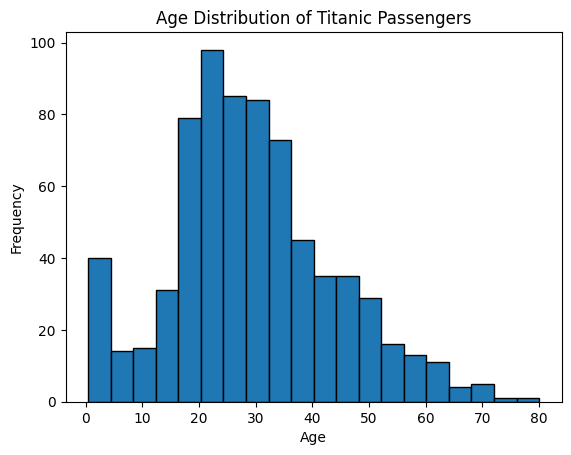

Mean age: 29.70


In [29]:
# Histogram of age distribution
import matplotlib.pyplot as plt 
plt.hist(df['Age'].dropna(), bins=20, edgecolor='black')
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print(f"Mean age: {df['Age'].mean():.2f}")

While we could just fill all missing age values in with the average, 29.7, this wouldn't make for a very good approximation as the ages of passengers vary wildly. Let's consider other ways to approximate a person's age.

### Age by Title
Someone's title can give clues about their age. We know that a Master is a boy under the age of 18, and we can guess that someone with a noble or military title is likely older than average. Let's break down the data and see what we get.

In [25]:
age_stats_by_title = (
    df.groupby('title', dropna=False)['Age']
    .agg(mean_age='mean', min_age='min', max_age='max', std_age='std')
    .sort_values('mean_age')
    .round(2)
)
print('Age statistics by title:')
print(age_stats_by_title)

missing_age_rows = df[df['Age'].isna()].copy().round(2)

print('\nTotal missing-age rows per title:')
missing_age_per_title = missing_age_rows['title'].value_counts(dropna=False).sort_index()
print(missing_age_per_title)

Age statistics by title:
              mean_age  min_age  max_age  std_age
title                                            
Master            4.57     0.42     12.0     3.62
Miss             21.77     0.75     63.0    12.99
Mme              24.00    24.00     24.0      NaN
Mlle             24.00    24.00     24.0     0.00
Ms               28.00    28.00     28.0      NaN
Mr               32.37    11.00     80.0    12.71
the Countess     33.00    33.00     33.0      NaN
Mrs              35.90    14.00     63.0    11.43
Jonkheer         38.00    38.00     38.0      NaN
Don              40.00    40.00     40.0      NaN
Dr               42.00    23.00     54.0    12.02
Rev              43.17    27.00     57.0    13.14
Lady             48.00    48.00     48.0      NaN
Major            48.50    45.00     52.0     4.95
Sir              49.00    49.00     49.0      NaN
Col              58.00    56.00     60.0     2.83
Capt             70.00    70.00     70.0      NaN

Total missing-age rows p

The above breakdown shows about what we would expect: boys and unmarried women are the youngest groups, Mr and Mrs are in the middle, and other honorifics trend upward in age. However, this isn't the whole picture. Notice the standard deviation. In some groups, standard deviation can vary by 11-13 years. This makes our age approximation less reliable for these groups.

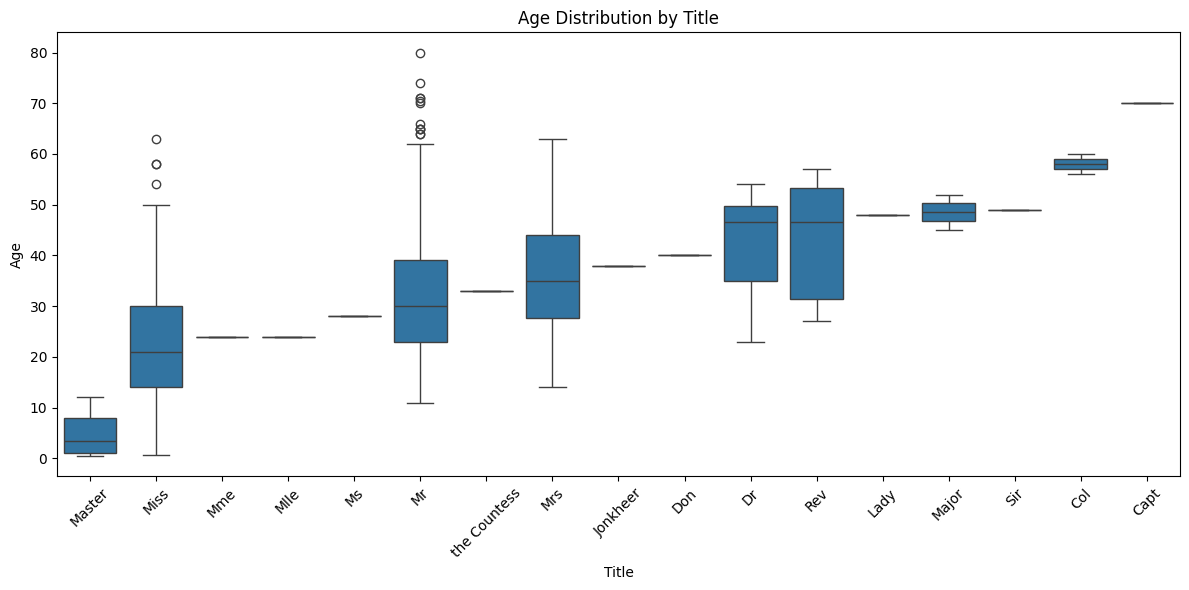

In [ ]:
plot_df = df.dropna(subset=['Age']).copy()
title_order = plot_df.groupby('title')['Age'].median().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_df, x='title', y='Age', order=title_order)
plt.title('Age Distribution by Title')
plt.xlabel('Title')
plt.ylabel('Age')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Where to go from here? Let's see if breaking down some of the larger groups reveals anything.

Class may mean something, as a Mr/Mrs/Miss travelling in first may be older.

In [40]:
mr_mrs_age_stats_by_class = (
    df[df['title'].isin(['Mr', 'Mrs', 'Miss'])]
    .groupby(['title', 'Pclass'])['Age']
    .agg(mean_age='mean', std_age='std')
    .round(2)
    .sort_index()
)

print('Average age and standard deviation by title (Mr/Mrs/Miss) and class:')
print(mr_mrs_age_stats_by_class)

Average age and standard deviation by title (Mr/Mrs/Miss) and class:
              mean_age  std_age
title Pclass                   
Miss  1          30.00    12.85
      2          22.39    13.37
      3          16.12     9.70
Mr    1          41.58    14.15
      2          32.77    11.85
      3          28.72    10.49
Mrs   1          40.88    12.64
      2          33.68    10.32
      3          33.52    10.03


The standard deviation here is smaller than before for some groups, making this a slightly more reliable estimate. Let's look deeper into 'Miss', as someone with that title could also be a child, and is unlikely to be travelling with their own children. This means that a 'Miss' with a Parch (parents and children) of 1+ is likely to be younger.

In [37]:
miss_age_stats_by_parch = (
    df[df['title'] == 'Miss']
    .groupby('Parch')['Age']
    .agg(mean_age='mean', std_age='std')
    .round(2)
    .sort_index()
)

print('Average age and standard deviation for Miss by Parch:')
print(miss_age_stats_by_parch)

Average age and standard deviation for Miss by Parch:
       mean_age  std_age
Parch                   
0         27.76    11.05
1          9.90     9.62
2         13.39     9.17


The standard deviation here is still relatively large, but smaller than the whole set of 'Miss' ages. This breakdown is therefore a more reliable way to fill in the missing values.

Can we go even more granular? Well, we could, for example, look at class + number of parents, but we'd be getting into situations where only a few data points represent that set. In a larger dataset, more granular combinations of features can be a way to approximate missing values, but in this set we'd likely be pushing our luck. Let's fill in the missing values as discussed.

In [47]:
# Fill in missing ages for Miss with Parch 1+ using the mean age for that group
for parch, mean_age in miss_age_stats_by_parch['mean_age'].items():
    condition = (df['title'] == 'Miss') & (df['Parch'] == parch) & (df['Age'].isna())
    df.loc[condition, 'Age'] = mean_age 
    
# Fill in missing ages for Mr and Mrs using the mean age for their title and class
for (title, pclass), stats in mr_mrs_age_stats_by_class.iterrows():
    mean_age = stats['mean_age']
    condition = (
        (df['title'] == title) &
        (df['Pclass'] == pclass) &
        (df['Age'].isna())
    )
    df.loc[condition, 'Age'] = mean_age

# Fill in missing ages for any remaining titles using the overall mean age for that title
for title, stats in age_stats_by_title.iterrows():
    mean_age = stats['mean_age']
    condition = (df['title'] == title) & (df['Age'].isna())
    df.loc[condition, 'Age'] = mean_age
    
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  title        891 non-null    str    
 13  rank         891 non-null    Int64  
dtypes: Int64(1), float64(2), int64(5), str(6)
memory usage: 98.5 KB


We'll also fill in Embarked missing values depe

## Is anything misleading to our model?

Determining if features may be misleading requires us to know about the data itself. Let's look at the fare compared to class and family size:

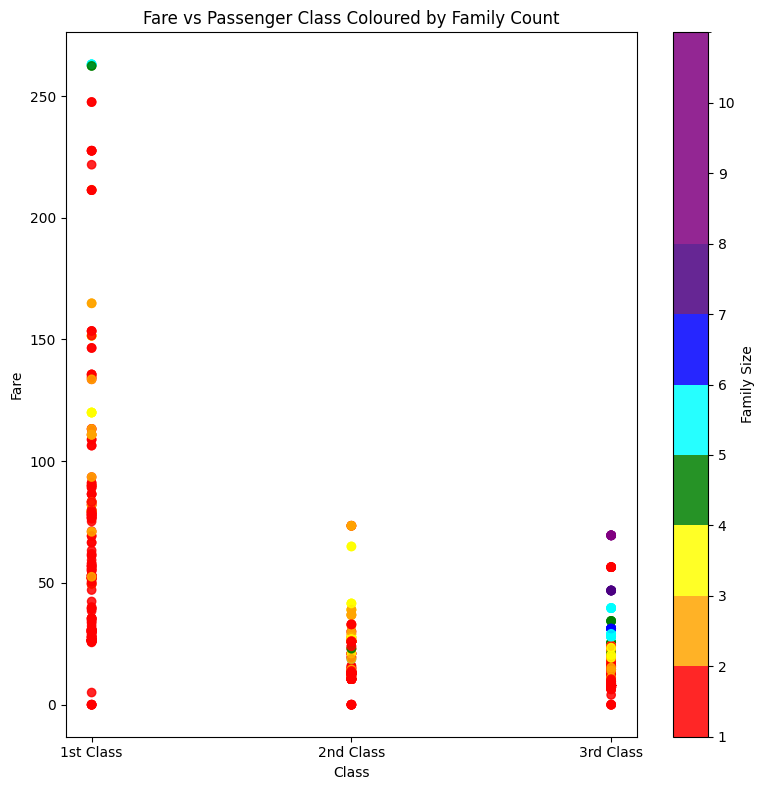

In [64]:
from matplotlib.colors import ListedColormap, BoundaryNorm

scatter_df = df.dropna(subset=['Pclass', 'Fare']).copy()

# Remove the max fare to improve visualisation
max_fare = scatter_df['Fare'].max()
scatter_df = scatter_df[scatter_df['Fare'] < max_fare]
scatter_df['family_count'] = (scatter_df['SibSp'] + scatter_df['Parch']).clip(1, 10)

# Colour map makes the last three (8,9,10) purple to avoid too many colours
custom_colours = [
    'red', 'orange', 'yellow', 'green', 'cyan',
    'blue', 'indigo', 'purple', 'purple', 'purple'
]
custom_cmap = ListedColormap(custom_colors)
bounds = list(range(1, 12))
norm = BoundaryNorm(bounds, custom_cmap.N)

plt.figure(figsize=(8, 8))
points = plt.scatter(
    scatter_df['Pclass'],
    scatter_df['Fare'],
    c=scatter_df['family_count'],
    cmap=custom_cmap,
    norm=norm,
    alpha=0.85
)

cbar = plt.colorbar(points, ticks=range(1, 11))
cbar.set_label('Family Size')

plt.title('Fare vs Passenger Class Coloured by Family Count')
plt.xlabel('Class')
plt.ylabel('Fare')
plt.xticks([1, 2, 3], ['1st Class', '2nd Class', '3rd Class'])
plt.tight_layout()
plt.show()

Broadly speaking, family size correlates to a higher fare. This tells us that the fare paid is for the whole family. That means fare can potentially be misleading, as for larger families they'll pay a larger fare, even if they weren't in a very high class.

In [70]:
# Add family size column
df['family_size'] = df['SibSp'] + df['Parch']

# Add individual fare column
df['individual_fare'] = df['Fare'] / (df['family_size'] + 1) # Add 1 to include the passenger


We'll keep the 'Fare' column for now, but may drop it during the actual machine learning.

## Reducing Multicollinearity

Multicollinearity occurs when features are highly correlated to each other. For example, someone's title is highly correlated to their class, which is correlated with how much they paid in fare. In many ML models, multicollinearity inflates standard error, which reduces interpretability. In general, it's a good idea to reduce the number of features that are highly related by either dropping features or combining them. We'll keep all features for now, but may drop or combine some later.

In [81]:
# Recover original text columns if a prior bad conversion turned everything into NaN
if df['Sex'].isna().all() or df['Embarked'].isna().all():
    raw_cols = pd.read_csv('titanic/train.csv', usecols=['Sex', 'Embarked'])
    df['Sex'] = raw_cols['Sex']
    df['Embarked'] = raw_cols['Embarked']

# Convert Sex to male = 0, female = 1
df['Sex'] = df['Sex'].replace({'male': 0, 'female': 1, 'Male': 0, 'Female': 1})
df['Sex'] = pd.to_numeric(df['Sex'], errors='coerce')

# Convert Embarked to S = 0, C = 1, Q = 2
df['Embarked'] = df['Embarked'].replace({'S': 0, 'C': 1, 'Q': 2, 's': 0, 'c': 1, 'q': 2})
df['Embarked'] = pd.to_numeric(df['Embarked'], errors='coerce')

# Drop PassengerId, Name, Ticket, Cabin, and title columns
#df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'title', 'surname'], inplace=True)

# Convert all columns to type float
df = df.astype(float)

df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,rank,family_size,individual_fare
0,0.0,3.0,0.0,22.00,1.0,0.0,7.2500,0.0,3.0,1.0,3.62500
1,1.0,1.0,1.0,38.00,1.0,0.0,71.2833,1.0,3.0,1.0,35.64165
2,1.0,3.0,1.0,26.00,0.0,0.0,7.9250,0.0,4.0,0.0,7.92500
3,1.0,1.0,1.0,35.00,1.0,0.0,53.1000,0.0,3.0,1.0,26.55000
4,0.0,3.0,0.0,35.00,0.0,0.0,8.0500,0.0,3.0,0.0,8.05000
...,...,...,...,...,...,...,...,...,...,...,...
886,0.0,2.0,0.0,27.00,0.0,0.0,13.0000,0.0,2.0,0.0,13.00000
887,1.0,1.0,1.0,19.00,0.0,0.0,30.0000,0.0,4.0,0.0,30.00000
888,0.0,3.0,1.0,13.39,1.0,2.0,23.4500,0.0,4.0,3.0,5.86250
889,1.0,1.0,0.0,26.00,0.0,0.0,30.0000,1.0,3.0,0.0,30.00000


In [82]:
df.to_csv('titanic/processed_train.csv', index=False)